### `Import necessary libraries`

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1789222958.438043  267638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789222958.438380  267638 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789222958.469894  267638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789222959.299998  267638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### `Load processed data`

In [4]:
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")

# Check the shapes of imported data

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (6954, 29)
X_val: (1739, 29)
y_train: (6954,)
y_val: (1739,)


### `Build the model`

In [5]:
model = Sequential([
    Dense(units=16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

/run/media/rifat-hasan/Felicitous/spaceship-titanic-ml/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789222961.984952  267638 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789222961.985341  268223 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789222961.998633  267638 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installe

### `Inspect the model`

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625 (2.44 KB)

 Trainable params: 625 (2.44 KB)

 Non-trainable params: 0 (0.00 B)

### `Compile the model`

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### `Train the Neural Network model`

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7075 - loss: 0.5868 - val_accuracy: 0.7602 - val_loss: 0.4912
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7873 - loss: 0.4604 - val_accuracy: 0.7838 - val_loss: 0.4421
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.7955 - loss: 0.4386 - val_accuracy: 0.7878 - val_loss: 0.4281
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.7987 - loss: 0.4310 - val_accuracy: 0.7913 - val_loss: 0.4224
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.8016 - loss: 0.4251 - val_accuracy: 0.7936 - val_loss: 0.4160
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.8037 - loss: 0.4218 - val_accuracy: 0.7924 - val_loss: 0.4128
Epoch 7/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - accuracy: 0.8010 - loss: 0.4177 - val_accuracy: 0.7924 - val_loss: 0.4094
Epoch 8/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.8036 - loss: 0.4154 - val_

### `Plot training history and validation history`

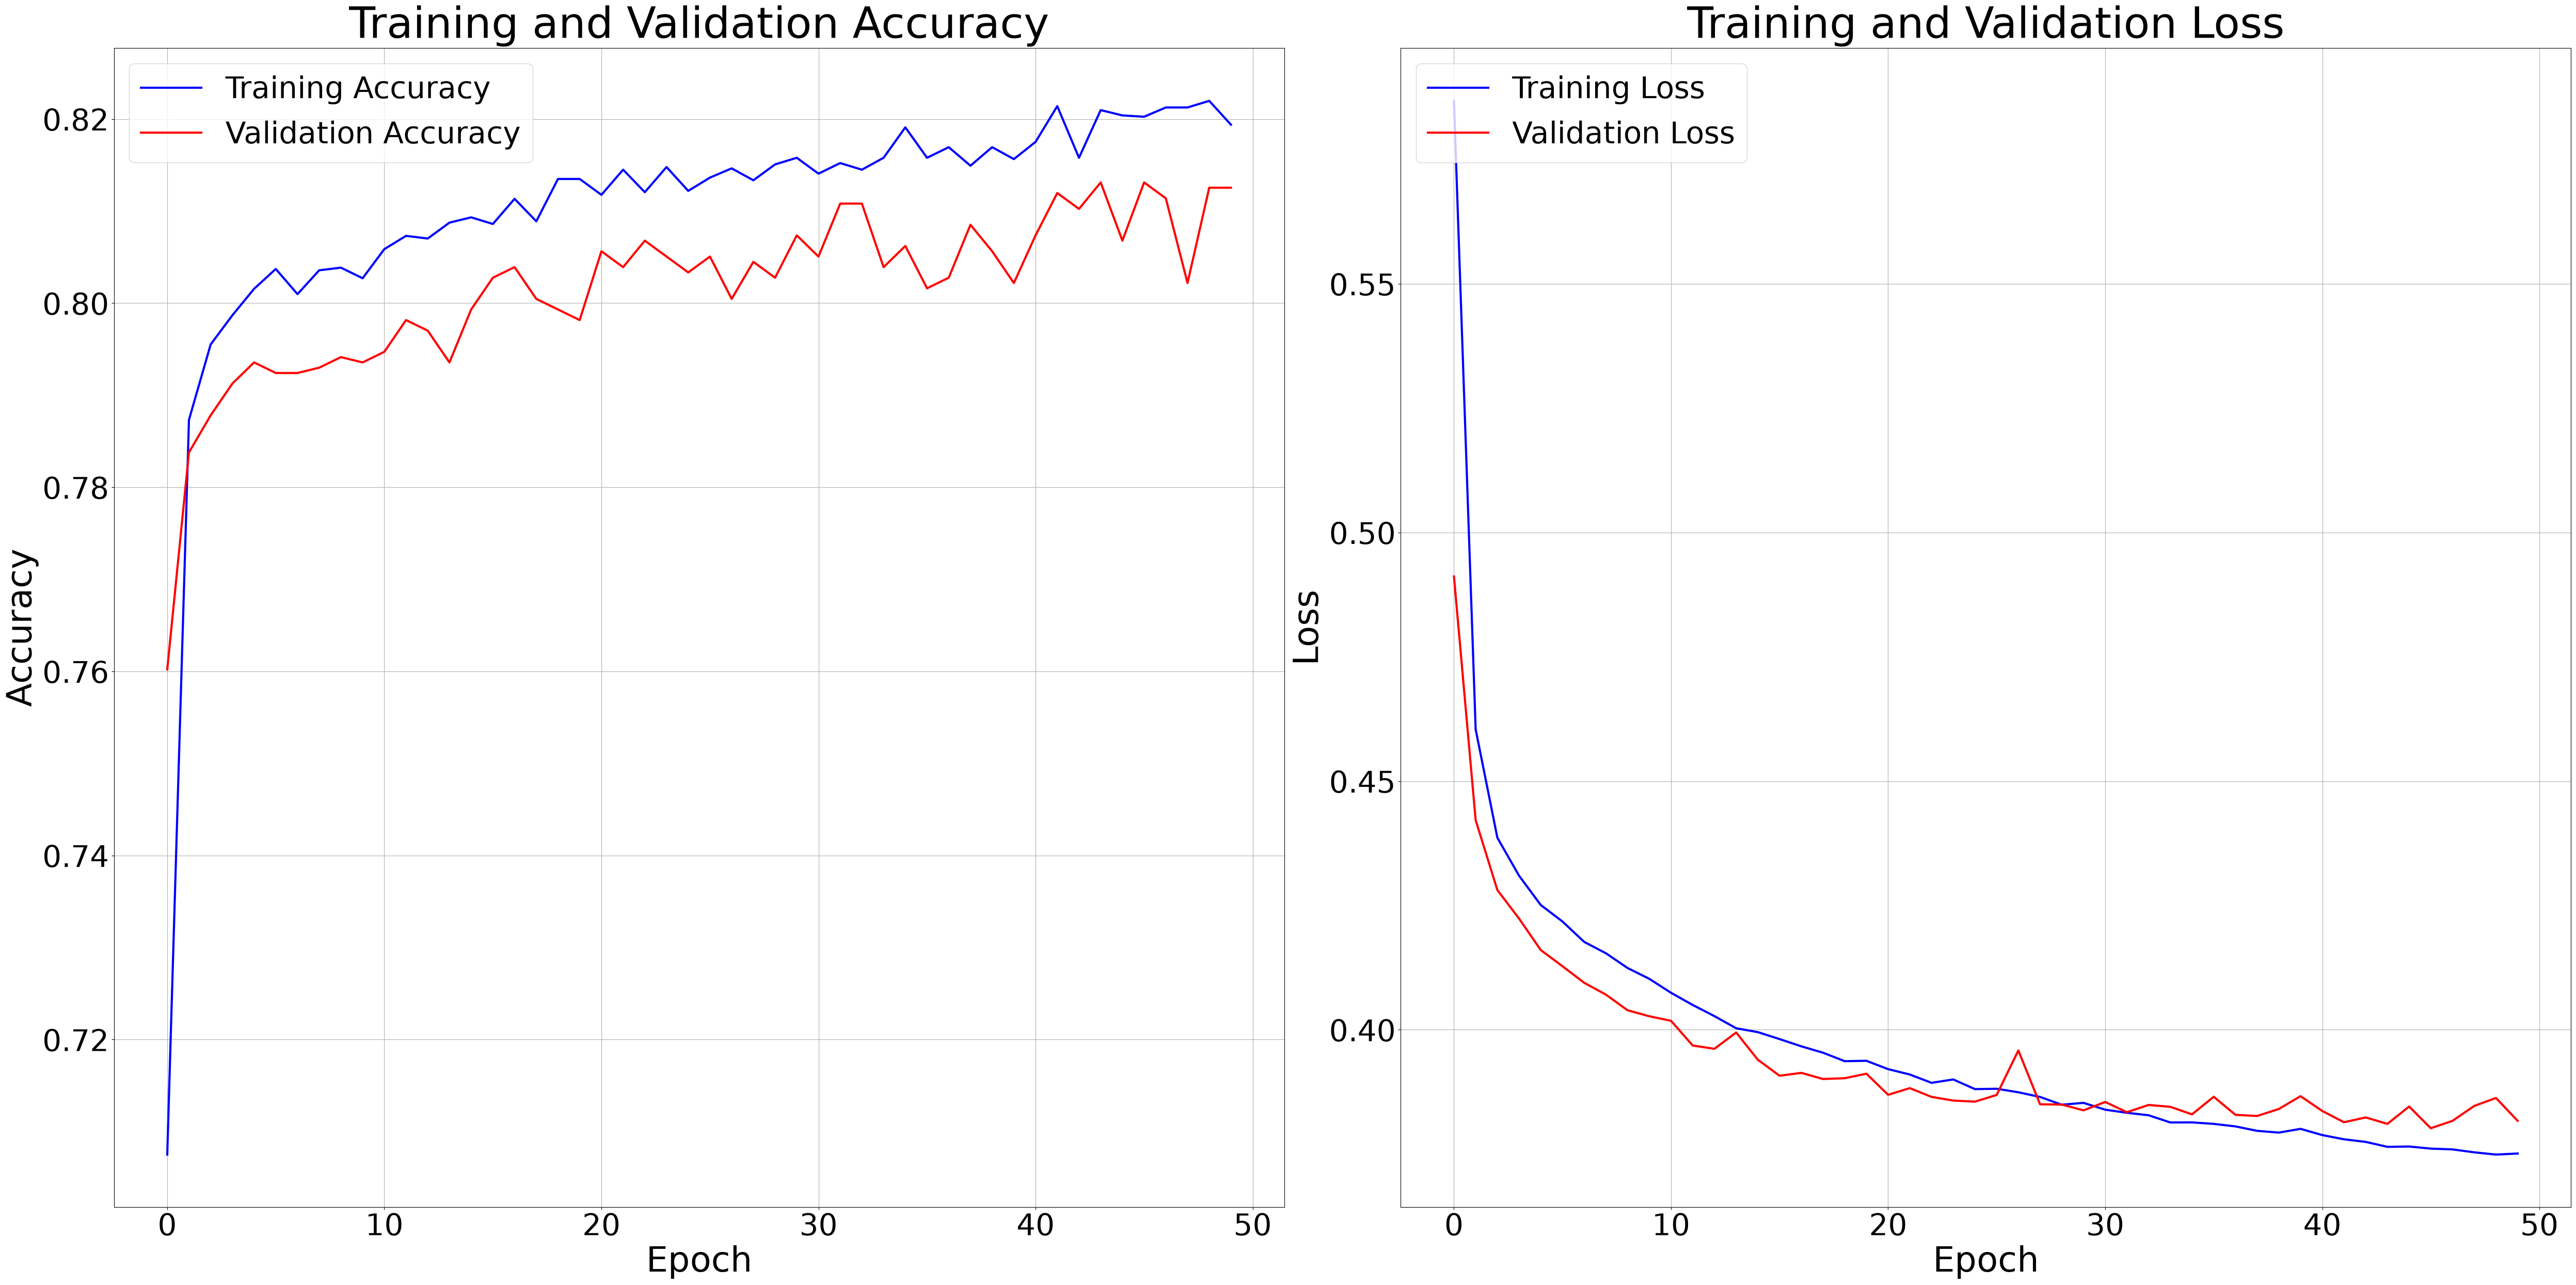

In [9]:
size_multiplier = 3

s = {
    "title_size": int(20 * size_multiplier),
    "label_size": int(16 * size_multiplier),
    "tick_size": int(14 * size_multiplier),
    "legend_size": int(14 * size_multiplier),
    "outlier_size": int(12 * size_multiplier)
}


fig, ax = plt.subplots(1, 2, figsize=(50, 25))

data_keys = {
    "accuracy": ("accuracy", "val_accuracy"),
    "loss": ("loss", "val_loss")
}

for i, (train_key, val_key) in enumerate(data_keys.values()):
    metric_name = "Accuracy" if train_key == "accuracy" else "Loss"

    ax[i].plot(
        history.history[train_key],
        label=f"Training {metric_name}",
        color="blue",
        linewidth=3
    )
    ax[i].plot(
        history.history[val_key],
        label=f"Validation {metric_name}",
        color="red",
        linewidth=3
    )

    ax[i].set_title(f"Training and Validation {metric_name}", fontsize=s["title_size"])
    ax[i].set_xlabel("Epoch", fontsize=s["label_size"])
    ax[i].set_ylabel(metric_name, fontsize=s["label_size"])
    ax[i].tick_params(axis="both", labelsize=s["tick_size"])
    ax[i].legend(fontsize=s["legend_size"], loc="upper left")
    ax[i].grid(True)

plt.tight_layout()
plt.show()


### `Evaluate the model`

In [10]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)  
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")  

Validation Loss: 0.3817
Validation Accuracy: 0.8125


In [11]:
probabilities = model.predict(X_val)

print(probabilities[:10])

predictions = probabilities >= 0.5
print(predictions[:10].astype(int))

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step
[[0.9770111 ]
 [0.8871757 ]
 [0.08832008]
 [0.9525274 ]
 [0.31015545]
 [0.57945836]
 [0.9864243 ]
 [0.5591142 ]
 [0.11203749]
 [0.7023382 ]]
[[1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]]


## `Result summary`

## Neural Network Results

### Architecture

- Hidden Layer 1: 16 neurons, ReLU
- Hidden Layer 2: 8 neurons, ReLU
- Output Layer: 1 neuron, Sigmoid

### Training Setup

- Loss: Binary Crossentropy
- Optimizer: Adam
- Metric: Accuracy
- Batch Size: 32
- Epochs: 50

### Performance

- Validation Accuracy: `0.8102`

### Comparison

- Logistic Regression Accuracy: `0.7872`
- Neural Network Accuracy: `0.8102`

The neural network is compared against Logistic Regression to determine
whether the additional model complexity improves validation performance.

### `Save the model`

In [12]:
model.save("../models/spaceship_titanic_nn.keras")

print("Model saved successfully.")

Model saved successfully.
